In [1]:
import uproot
import pandas as pd
import awkward as ak
import joblib
import os
import matplotlib.pyplot as plt  
import mplhep as hep  
import numpy as np
import zfit
from zfit import z
from zfit.loss import ExtendedUnbinnedNLL
from zfit.minimizers.minimizer_minuit import Minuit
import json
import warnings

/home/tandrade/.local/lib/python3.9/site-packages/zfit/__init__.py:63: UserWarning: TensorFlow warnings are by default suppressed by zfit. In order to show them, set the environment variable ZFIT_DISABLE_TF_WARNINGS=0. In order to suppress the TensorFlow warnings AND this warning, set ZFIT_DISABLE_TF_WARNINGS=1.
  warnings.warn(


In [6]:
signal_path = "/home/tandrade/Flavour_Anomalies/Data/Signal_Data.root"  
model_path  = "/home/tandrade/Flavour_Anomalies/Machine_Learning/final_bdt_model.joblib"  
tree_name   = "tree_ML"

In [7]:
model = joblib.load(model_path)

In [8]:
features = [
    'BToTrkTrkMuMu_l_xy_sig_good',           
    'BToTrkTrkMuMu_dca_sig_good',            
    'BToTrkTrkMuMu_trk1_dca_sig_good',       
    'BToTrkTrkMuMu_trk2_dca_sig_good',       
    'BToTrkTrkMuMu_fit_ditrack_mass_Kpi_good',
    'BToTrkTrkMuMu_fit_cos2D_good', 
    'BToTrkTrkMuMu_svprob_good',
    'BToTrkTrkMuMu_fit_pt_good'
]

In [9]:
signal_file = uproot.open(signal_path)[tree_name]
signal_ak = signal_file.arrays(library="ak")
signal_df = ak.to_dataframe(signal_ak)

In [10]:
signal_df.replace([np.inf, -np.inf], np.nan, inplace=True)
signal_df = signal_df.dropna()

In [11]:
probabilities = model.predict_proba(signal_df[features])[:, 1]
predictions = model.predict(signal_df[features])

In [12]:
signal_df['bdt_score'] = probabilities
signal_df['bdt_prediction'] = predictions

In [13]:
bdt_cut = 0.92  # Mesmo valor que você usou
df_signal_like = signal_df[signal_df['bdt_score'] > bdt_cut]

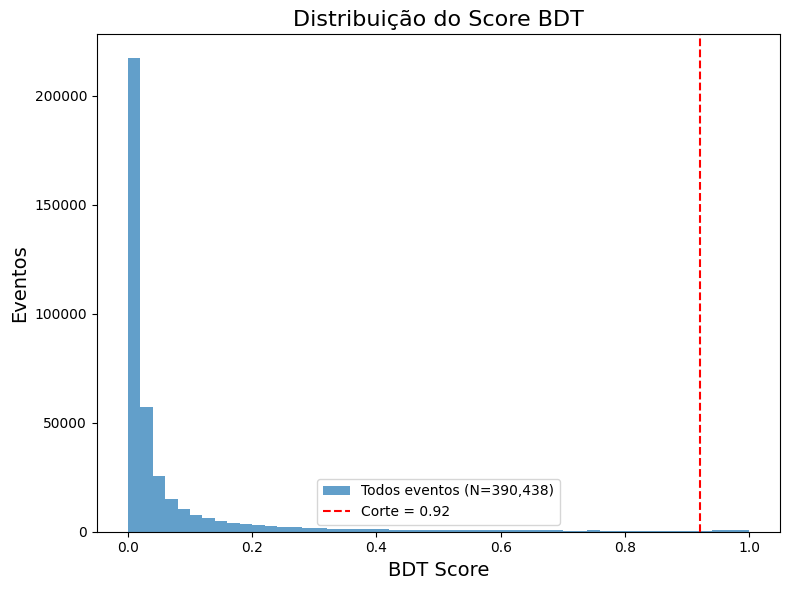

In [14]:
plt.figure(figsize=(8, 6))
plt.hist(signal_df['bdt_score'], bins=50, alpha=0.7, 
         label=f'Todos eventos (N={len(signal_df):,})')
plt.axvline(x=bdt_cut, color='red', linestyle='--', 
           label=f'Corte = {bdt_cut}')
plt.xlabel('BDT Score', fontsize=14)
plt.ylabel('Eventos', fontsize=14)
plt.title('Distribuição do Score BDT', fontsize=16)
plt.legend()
#plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
plt.close()

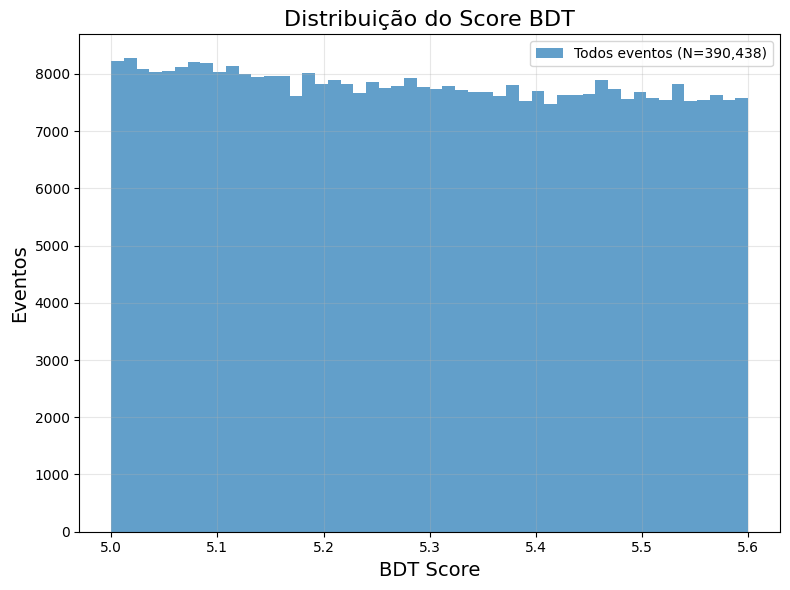

In [15]:
plt.figure(figsize=(8, 6))
plt.hist(signal_df['BToTrkTrkMuMu_fit_mass_Kpi_good'], bins=50, range = (5, 5.6), alpha=0.7, label=f'Todos eventos (N={len(signal_df):,})')
plt.xlabel('BDT Score', fontsize=14)
plt.ylabel('Eventos', fontsize=14)
plt.title('Distribuição do Score BDT', fontsize=16)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
plt.close()

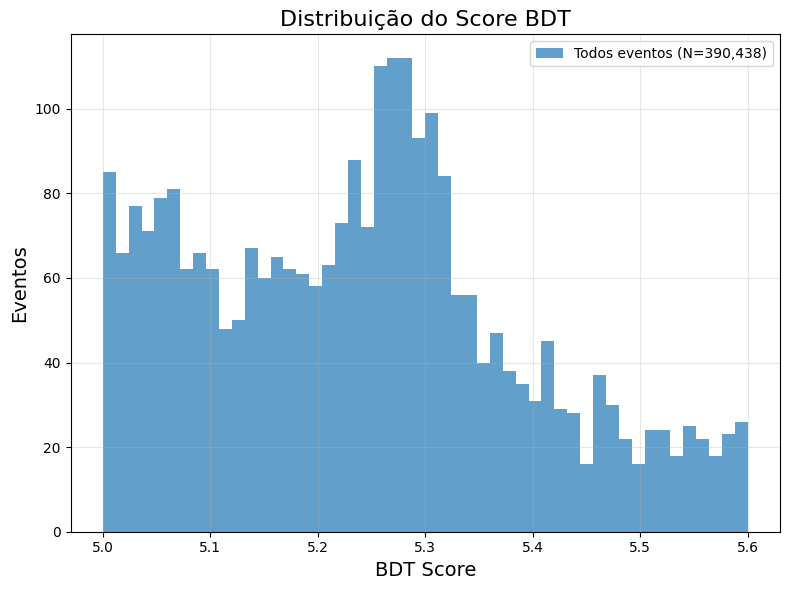

In [16]:
plt.figure(figsize=(8, 6))
plt.hist(df_signal_like['BToTrkTrkMuMu_fit_mass_Kpi_good'], bins=50, range = (5, 5.6), alpha=0.7, label=f'Todos eventos (N={len(signal_df):,})')
plt.xlabel('BDT Score', fontsize=14)
plt.ylabel('Eventos', fontsize=14)
plt.title('Distribuição do Score BDT', fontsize=16)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
plt.close()

In [17]:
import zfit
import numpy as np
from zfit import z  # Opcional, para facilitar acesso

# --- 1. PREPARAÇÃO DOS DADOS (Corrigida) ---

# Supondo que a coluna de massa no DataFrame se chama 'B0_mass'
coluna_massa = 'BToTrkTrkMuMu_fit_mass_Kpi_good' 
mass_min = 5.0
mass_max = 5.6

# Aplicar corte do BDT
df_bdt_cut = df_signal_like[df_signal_like['bdt_score'] > bdt_cut]

# Filtrar eventos na janela de sinal (Usando a coluna específica!)
mask = (df_bdt_cut[coluna_massa] >= mass_min) & (df_bdt_cut[coluna_massa] <= mass_max)
df_final = df_bdt_cut[mask]

# *** A CORREÇÃO ESTÁ AQUI ***
# Extrair apenas a coluna de massa como array numpy
data_array = df_final[coluna_massa].to_numpy()

print(f"Eventos para o fit: {len(data_array)}")


# --- 2. CONFIGURAÇÃO DO ZFIT ---

obs = zfit.Space(coluna_massa, limits=(mass_min, mass_max))

# Parâmetros
mu = zfit.Parameter("mu", 5.279, mass_min, mass_max)
sigma = zfit.Parameter("sigma", 0.025, 0.005, 0.1)
tau = zfit.Parameter("tau", -2.0, -10.0, 0.0)

# Yields (Extended Fit)
n_total = len(data_array)
nsig = zfit.Parameter("nsig", int(n_total * 0.4), 0, n_total * 2)
nbkg = zfit.Parameter("nbkg", int(n_total * 0.6), 0, n_total * 2)

# PDFs
signal_pdf = zfit.pdf.Gauss(mu=mu, sigma=sigma, obs=obs, extended=nsig)
bkg_pdf = zfit.pdf.Exponential(lambda_=tau, obs=obs, extended=nbkg)
total_pdf = zfit.pdf.SumPDF([signal_pdf, bkg_pdf])

# --- 3. CRIAÇÃO DO DATA E FIT (Corrigido) ---

# Agora passamos o 'data_array' que é puramente numpy
data_z = zfit.Data.from_numpy(obs=obs, array=data_array)

# Loss function
loss = zfit.loss.ExtendedUnbinnedNLL(model=total_pdf, data=data_z)

# Minimização
print(f"Executando minimização...")
minimizer = zfit.minimize.Minuit()
result = minimizer.minimize(loss)

print(result)

Eventos para o fit: 2732
Executando minimização...
FitResult of
<ExtendedUnbinnedNLL model=[<zfit.<class 'zfit.models.functor.SumPDF'>  params=[Composed_autoparam_1, Composed_autoparam_2]] data=[<zfit.Data: Data obs=('BToTrkTrkMuMu_fit_mass_Kpi_good',) shape=(2732, 1)>] constraints=[]> 
with
<Minuit Minuit tol=0.001>

╒═════════╤═════════════╤══════════════════╤═════════╤══════════════════════════════╕
│  valid  │  converged  │  param at limit  │   edm   │   approx. fmin (full | opt.) │
╞═════════╪═════════════╪══════════════════╪═════════╪══════════════════════════════╡
│  True   │    True     │      False       │ 0.00036 │         -1702.64 |  9767.835 │
╘═════════╧═════════════╧══════════════════╧═════════╧══════════════════════════════╛

Parameters
name      value  (rounded)    at limit
------  ------------------  ----------
nsig               540.292       False
nbkg               2191.47       False
mu                 5.27808       False
sigma            0.0391391       False
tau 

Fit convergiu com sucesso!


KeyError: 'hesse'

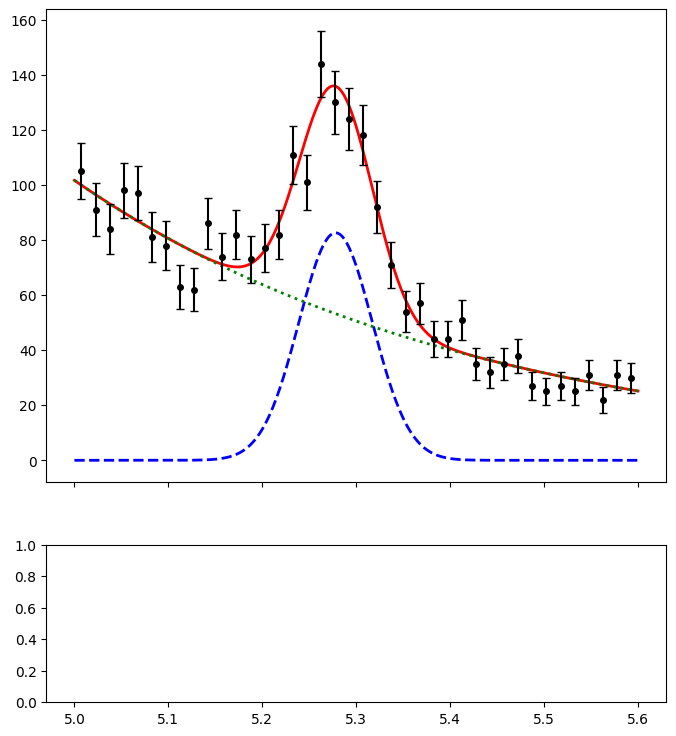

In [18]:
# ... (seu código anterior até o fit) ...

if result.valid:
    print("Fit convergiu com sucesso!")
else:
    print("Aviso: O fit não convergiu completamente.")

# ---------------------------------------------------------
# CÓDIGO DO PLOT CORRIGIDO
# ---------------------------------------------------------

fig, (ax_main, ax_res) = plt.subplots(2, 1, figsize=(8, 9), 
                           gridspec_kw={'height_ratios': [3, 1]},
                           sharex=True)

# Histograma dos dados
bins_fit = 40
# USAR data_array que você já definiu anteriormente
# mass_filtered não existe, use data_array em vez disso
data_array = data_array if isinstance(data_array, np.ndarray) else data_array.to_numpy()
if len(data_array.shape) > 1: 
    data_array = data_array.flatten() # Garantir 1D

counts, edges = np.histogram(data_array, bins=bins_fit, range=(mass_min, mass_max))
centers = 0.5 * (edges[:-1] + edges[1:])
width = edges[1] - edges[0]

# Erros (Poisson)
yerr = np.sqrt(counts)
yerr[yerr == 0] = 1 

# Plot dados
ax_main.errorbar(centers, counts, yerr=yerr, fmt='o', color='black', 
    markersize=4, capsize=3, label='Dados', zorder=10)

x_fit = np.linspace(mass_min, mass_max, 500)

# Escala para plotagem
scale_factor = width # A largura do bin dos dados

pdf_total = total_pdf.pdf(x_fit).numpy() * (nsig.value() + nbkg.value()) * scale_factor
pdf_sig = signal_pdf.pdf(x_fit).numpy() * nsig.value() * scale_factor
pdf_bkg = bkg_pdf.pdf(x_fit).numpy() * nbkg.value() * scale_factor

ax_main.plot(x_fit, pdf_total, 'r-', linewidth=2, label='Fit total')
ax_main.plot(x_fit, pdf_sig, 'b--', linewidth=2, label='Sinal (Gauss)')
ax_main.plot(x_fit, pdf_bkg, 'g:', linewidth=2, label='Fundo (Exp)')

# Texto com resultados
fit_text = (
    rf"$N_{{sig}} = {nsig.value():.0f} \pm {result.params[nsig]['hesse']['error']:.0f}$" + "\n" +
    rf"$N_{{bkg}} = {nbkg.value():.0f} \pm {result.params[nbkg]['hesse']['error']:.0f}$" + "\n" +
    rf"$\mu = {mu.value():.4f} \pm {result.params[mu]['hesse']['error']:.4f}$ GeV" + "\n"
)

ax_main.text(0.05, 0.95, fit_text, transform=ax_main.transAxes, fontsize=12, verticalalignment='top',
             bbox=dict(boxstyle='round', facecolor='white', alpha=0.9))

# Resíduos
expected_counts = total_pdf.pdf(centers).numpy() * (nsig.value() + nbkg.value()) * width
residuals = (counts - expected_counts) / yerr

ax_res.axhline(y=0, color='gray', linestyle='-', alpha=0.5)
ax_res.errorbar(centers, residuals, yerr=1, fmt='o', 
       color='black', markersize=3, capsize=2)

ax_res.set_ylabel("Pull (Resíduos)", fontsize=12)
ax_res.set_ylim(-4, 4)
ax_res.grid(True, alpha=0.3)

ax_main.set_ylabel(f"Eventos / ({width:.3f} GeV)", fontsize=14)
ax_main.legend(fontsize=12, loc='upper right')
#ax_main.grid(True, alpha=0.3)

ax_res.set_xlabel(r"$m(K^{+}\pi^{-}\mu^{+}\mu^{-})$ [GeV]", fontsize=14)

# Adicionar informações do corte
cut_info = f"Corte BDT: > {bdt_cut}"
ax_main.text(0.05, 0.05, cut_info,
    transform=ax_main.transAxes,
    fontsize=10,
    verticalalignment='bottom',
    bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.8))

hep.cms.label("Work in Progress", data=True, com=13.6, ax=ax_main, fontsize=14)

plt.tight_layout()
plt.savefig("Plots/Fit_Result.png")
plt.show()